# Wing Design — Electric V-BAT-Like Tail-Sitter (EDF)

This notebook covers airfoil and wing geometry sizing.
It picks up directly from the converged mass iteration loop
and the constraint diagram outputs.

All numerical values are computed in the code cells below.
Do not hardcode mass, weight, or wing loading here.

Notebook flow:
  1. Imports and design point inputs
  2. Wing area and stall speed
  3. Airfoil selection rationale
  4. NACA 4-digit geometry
  5. Lift curve slope
  6. CL-CD polar
  7. Span, chord, AR, taper
  8. Reynolds number check
  9. Cruise validation
 10. AR trade study
 11. Summary

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

Matplotlib is building the font cache; this may take a moment.


## 1. Design Point Inputs

Mass and weight come directly from the converged sizing loop.
Wing loading and cruise T/W come from the constraint diagram notebook.
Do not hardcode these values here.

In [2]:
from conceptual_design import (
    run_sizing_loop, SizingResult,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
import yaml
from pathlib import Path

# --- load configs (same as mass iteration notebook) ---
env     = Environment()
mission = Mission.from_yaml("../config/mission.yaml")
aero    = Aerodynamics.from_yaml("../config/aerodynamics.yaml")
batt    = Battery.from_yaml("../config/battery.yaml")
wf      = WeightFraction.from_yaml("../config/initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml("../config/propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml("../config/forward_flight_params.yaml")   # <-- FIXED
ws      = WingStructureParams.from_yaml("../config/wing_structure_params.yaml")   # <-- FIXED

# --- run sizing loop ---
result  = run_sizing_loop(
    m_payload_kg = 0.5,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = 0.28,
    disk_loading = 150.0,
)

# --- pull the values this notebook needs ---
m_total  = result.m_total_kg
W        = m_total * env.g
V_cruise = mission.V_cruise

print(f"Converged mass  m_total = {m_total:.3f} kg")
print(f"Vehicle weight  W       = {W:.2f} N")

Converged mass  m_total = 2.102 kg
Vehicle weight  W       = 20.61 N


## 2. Wing Area and Stall Speed

The design wing loading comes from the Size Matching Diagram in the
conceptual-design notebook.  Once MTOW and W/S are known, wing area
and span follow directly.

Stall speed check:
$$V_{stall} = \sqrt{\frac{2 \, W/S}{\rho \, C_{L,max}}}$$

In [3]:
from conceptual_design.forward_flight_power import compute_size_matching_diagram
from conceptual_design.wing_sizing import size_wing

# -- Re-run the size matching diagram to get the design point ----------
smd = compute_size_matching_diagram(
    aero           = aero,
    mission        = mission,
    ff             = ff,
    env            = env,
    eta_propulsive = prop.eta_total,
)

WS_design = smd.WS_design    # [N/m^2]  design wing loading
TW_design = smd.TW_design    # [-]      design thrust-to-weight

# -- Wing geometry ------------------------------------------------------
wing = size_wing(
    MTOW_kg   = m_total,
    WS_design = WS_design,
    TW_design = TW_design,
    aero      = aero,
    mission_V = V_cruise,
    ws        = ws,
    env       = env,
)

# -- Stall speed --------------------------------------------------------
import math
V_stall = math.sqrt(2.0 * WS_design / (env.rho * aero.CL_max))

print(f"Design wing loading : {WS_design:.1f} N/m^2")
print(f"Wing area           : {wing.S_wing:.4f} m^2")
print(f"Wing span           : {wing.b_wing:.4f} m")
print(f"Mean chord (MAC)    : {wing.chord_mean:.4f} m")
print(f"Wing mass (Raymer)  : {wing.mass_wing_kg:.4f} kg")
print(f"Stall speed         : {V_stall:.2f} m/s  (require <= {aero.V_stall:.1f} m/s)")
stall_ok = V_stall <= aero.V_stall * 1.02   # 2 % numerical margin
print(f"Stall constraint    : {'OK' if stall_ok else 'VIOLATED'}")

Design wing loading : 123.2 N/m^2
Wing area           : 0.1674 m^2
Wing span           : 1.0022 m
Mean chord (MAC)    : 0.1670 m
Wing mass (Raymer)  : 0.1016 kg
Stall speed         : 11.98 m/s  (require <= 12.0 m/s)
Stall constraint    : OK


## 3. Airfoil Selection Rationale

For a tail-sitter EDF operating at Re ~ 3×10⁵ – 8×10⁵ the wing must
satisfy three competing requirements:

| Requirement | Driver |
|---|---|
| Low profile drag | cruise endurance |
| Adequate Cl_max | stall speed at design W/S |
| t/c ≥ 0.09 | spar depth for structural stiffness |

Candidate sections are defined in `config/airfoil_selection.yaml`.
The analysis below compares them and selects the best-fit airfoil.

In [4]:
import yaml as _yaml
from pathlib import Path
from conceptual_design.airfoil_selection import analyse_airfoil, compare_airfoils

# -- Load airfoil config ------------------------------------------------
CONFIG_PATH = REPO_ROOT / "config"
with open(CONFIG_PATH / "airfoil_selection.yaml", "r", encoding="utf-8") as _f:
    _af_cfg = _yaml.safe_load(_f)

DESIGNATION  = _af_cfg["designation"]     # e.g. "NACA 2412"
CD0_FUSELAGE = _af_cfg["CD0_fuselage"]    # fuselage drag contribution

# -- Side-by-side comparison of candidate airfoils ----------------------
candidates = ["NACA 0012", "NACA 2412", "NACA 4412", "NACA 2415"]
print("Airfoil comparison  (AR={:.1f}, W/S={:.0f} N/m^2, V={:.0f} m/s)\n".format(
    aero.AR, WS_design, V_cruise))
compare_airfoils(
    candidates   = candidates,
    AR           = aero.AR,
    WS_N_m2      = WS_design,
    V_cruise     = V_cruise,
    V_stall      = aero.V_stall,
    rho          = env.rho,
)
print(f"\nSelected : {DESIGNATION}  (from config/airfoil_selection.yaml)")

Airfoil comparison  (AR=6.0, W/S=123 N/m^2, V=20 m/s)

Designation       t/c   Cl_max   CL_max3D      Cd0      L/D  Warns
------------------------------------------------------------------
NACA 0012       0.120   1.0540     0.9486  0.01260    13.22  2!
NACA 2412       0.120   1.3540     1.2186  0.01260    13.22  2!
NACA 4412       0.120   1.6540     1.4886  0.01260    13.22  1!
NACA 2415       0.150   1.4300     1.2870  0.01605    12.12  2!

Selected : NACA 2412  (from config/airfoil_selection.yaml)


## 4. NACA 4-Digit Geometry

The selected airfoil is analysed in full and its upper/lower surface
coordinates are plotted at unit chord.

Thickness distribution (NACA standard):
$$y_t = 5t\bigl(0.2969\sqrt{x} - 0.1260x - 0.3516x^2 + 0.2843x^3 - 0.1015x^4\bigr)$$

NACA 2412
  Max camber       M = 0.0200  (2.0% chord)
  Camber location  P = 0.40   (40% chord)
  Thickness        t = 0.1200  (12.0% chord)


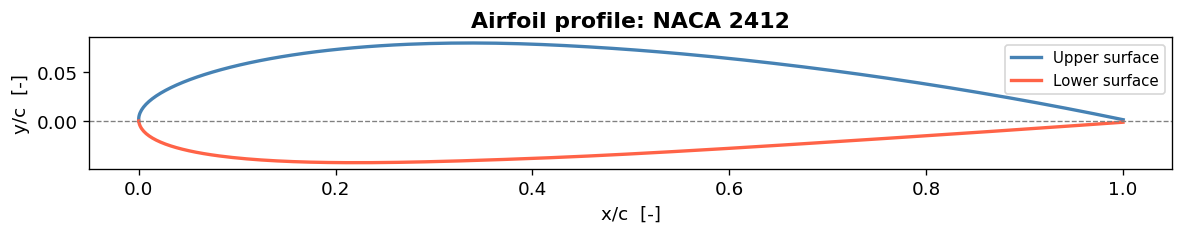

In [5]:
from conceptual_design.airfoil_selection import (
    parse_naca4, naca4_coordinates, analyse_airfoil, write_outputs,
)

M, P, t = parse_naca4(DESIGNATION)
print(f"{DESIGNATION}")
print(f"  Max camber       M = {M:.4f}  ({M*100:.1f}% chord)")
print(f"  Camber location  P = {P:.2f}   ({P*100:.0f}% chord)")
print(f"  Thickness        t = {t:.4f}  ({t*100:.1f}% chord)")

# -- Plot the airfoil profile -------------------------------------------
xu, yu, xl, yl = naca4_coordinates(M, P, t, n=200)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xu, yu, color='steelblue', lw=2, label='Upper surface')
ax.plot(xl, yl, color='tomato',    lw=2, label='Lower surface')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_aspect('equal')
ax.set_xlabel('x/c  [-]')
ax.set_ylabel('y/c  [-]')
ax.set_title(f'Airfoil profile: {DESIGNATION}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('airfoil_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Lift Curve Slope

**2D section** (thin airfoil + thickness correction, Abbott & von Doenhoff):
$$C_{l,\alpha} = 2\pi\,(1 + 0.77\,t)  \quad [\text{per rad}]$$

**3D finite wing** (Prandtl lifting-line):
$$C_{L,\alpha} = \frac{C_{l,\alpha}}{1 + C_{l,\alpha}/(\pi\,AR\,e)}$$

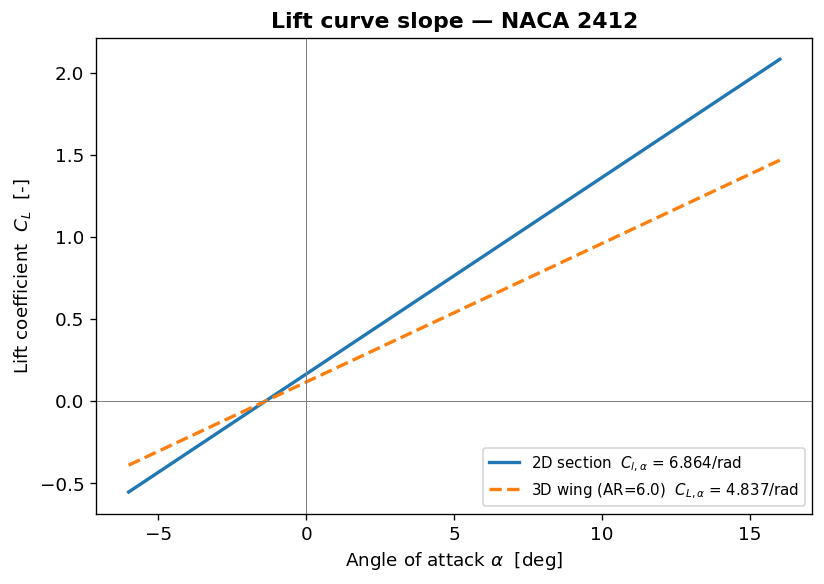

2D  Cl_alpha = 6.8638 /rad  (393.2640 /deg)
3D  CL_alpha = 4.8371 /rad
    alpha_L0 = -1.375 deg
    Oswald e = 0.8691


In [6]:
from conceptual_design.airfoil_selection import (
    section_Cl_alpha, wing_CL_alpha, oswald_efficiency,
    section_alpha_L0,
)

Cl_a_2D  = section_Cl_alpha(t)
e_oswald = oswald_efficiency(aero.AR)
CL_a_3D  = wing_CL_alpha(Cl_a_2D, aero.AR, e_oswald)
aL0_deg  = math.degrees(section_alpha_L0(M, P))

# -- Plot Cl vs alpha (2D) and CL vs alpha (3D) -------------------------
alpha_deg = np.linspace(-6, 16, 200)
alpha_rad = np.radians(alpha_deg)

Cl_2D = Cl_a_2D * (alpha_rad - math.radians(aL0_deg))
CL_3D = CL_a_3D * (alpha_rad - math.radians(aL0_deg))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(alpha_deg, Cl_2D, lw=2, label=f'2D section  $C_{{l,\\alpha}}$ = {Cl_a_2D:.3f}/rad')
ax.plot(alpha_deg, CL_3D, lw=2, ls='--',
        label=f'3D wing (AR={aero.AR})  $C_{{L,\\alpha}}$ = {CL_a_3D:.3f}/rad')
ax.axhline(0, color='gray', lw=0.6)
ax.axvline(0, color='gray', lw=0.6)
ax.set_xlabel(r'Angle of attack $\alpha$  [deg]')
ax.set_ylabel(r'Lift coefficient  $C_L$  [-]')
ax.set_title(f'Lift curve slope — {DESIGNATION}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('lift_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"2D  Cl_alpha = {Cl_a_2D:.4f} /rad  ({math.degrees(Cl_a_2D):.4f} /deg)")
print(f"3D  CL_alpha = {CL_a_3D:.4f} /rad")
print(f"    alpha_L0 = {aL0_deg:.3f} deg")
print(f"    Oswald e = {e_oswald:.4f}")

## 6. CL–CD Polar

Parabolic drag polar for the 3D wing:
$$C_D = C_{D0} + k\,C_L^2, \qquad k = \frac{1}{\pi\,AR\,e}$$

$C_{D0}$ includes both the wing profile drag and the fuselage/misc
contribution loaded from `config/airfoil_selection.yaml`.

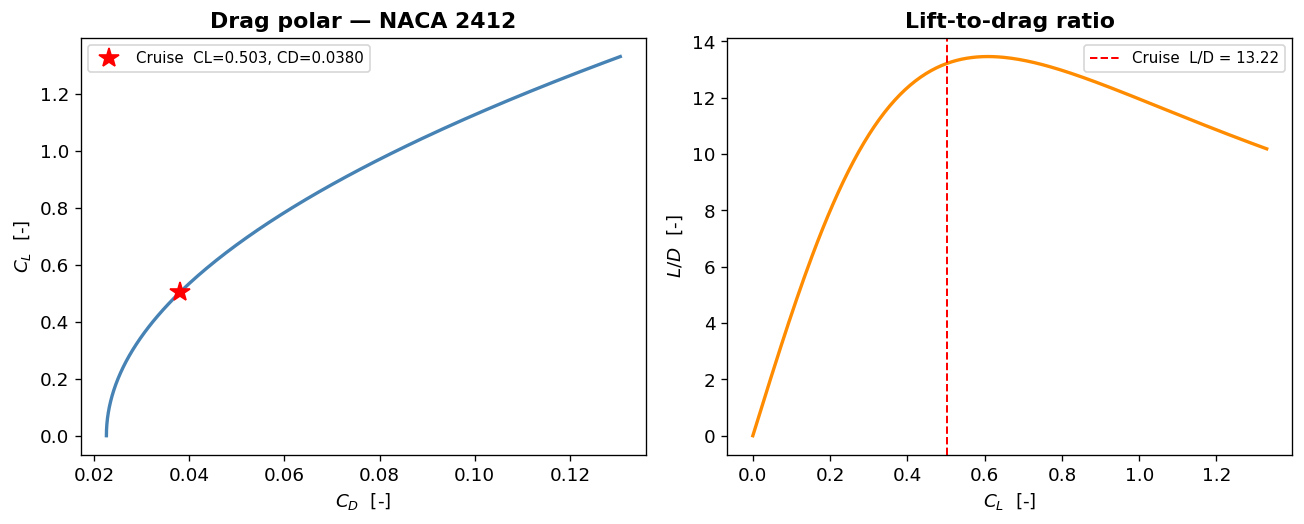

Cd0 section  : 0.01260
CD0 total    : 0.02260  (incl. 0.010 fuselage)
k (induced)  : 0.06104
CL cruise    : 0.5027
L/D cruise   : 13.22


In [7]:
from conceptual_design.airfoil_selection import section_Cd0

Cd0_section = section_Cd0(t)
CD0_total   = Cd0_section + CD0_FUSELAGE
k_induced   = 1.0 / (math.pi * aero.AR * e_oswald)

# -- Drag polar ---------------------------------------------------------
CL_range = np.linspace(0, aero.CL_max * 0.95, 200)
CD_range = CD0_total + k_induced * CL_range**2

# Cruise operating point
q_cruise  = 0.5 * env.rho * V_cruise**2
CL_cruise = WS_design / q_cruise
CD_cruise = CD0_total + k_induced * CL_cruise**2
LD_cruise = CL_cruise / CD_cruise

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: polar
ax = axes[0]
ax.plot(CD_range, CL_range, lw=2, color='steelblue')
ax.plot(CD_cruise, CL_cruise, 'r*', ms=12, zorder=5,
        label=f'Cruise  CL={CL_cruise:.3f}, CD={CD_cruise:.4f}')
ax.set_xlabel(r'$C_D$  [-]')
ax.set_ylabel(r'$C_L$  [-]')
ax.set_title(f'Drag polar — {DESIGNATION}', fontweight='bold')
ax.legend(fontsize=9)

# Right: L/D vs CL
LD_range = CL_range / CD_range
ax2 = axes[1]
ax2.plot(CL_range, LD_range, lw=2, color='darkorange')
ax2.axvline(CL_cruise, color='red', lw=1.2, ls='--',
            label=f'Cruise  L/D = {LD_cruise:.2f}')
ax2.set_xlabel(r'$C_L$  [-]')
ax2.set_ylabel(r'$L/D$  [-]')
ax2.set_title('Lift-to-drag ratio', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cl_cd_polar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cd0 section  : {Cd0_section:.5f}")
print(f"CD0 total    : {CD0_total:.5f}  (incl. {CD0_FUSELAGE:.3f} fuselage)")
print(f"k (induced)  : {k_induced:.5f}")
print(f"CL cruise    : {CL_cruise:.4f}")
print(f"L/D cruise   : {LD_cruise:.2f}")

## 7. Span, Chord, AR, Taper

Geometry relationships for a simple rectangular planform
(taper ratio λ = 1, no sweep):

$$b = \sqrt{AR \cdot S}, \qquad c_{MAC} = \frac{S}{b} = \sqrt{\frac{S}{AR}}$$

These are the same values computed by `size_wing()`; this section
makes the geometry parameters explicit and checks the 3 m size constraint.

In [8]:
S_wing    = wing.S_wing
b_wing    = wing.b_wing
c_mac     = wing.chord_mean
AR_check  = b_wing**2 / S_wing      # must equal aero.AR
sweep_deg = math.degrees(ws.sweep_rad)

print(f"Wing planform summary")
print(f"  Wing area   S   = {S_wing:.4f} m^2")
print(f"  Span        b   = {b_wing:.4f} m")
print(f"  MAC chord   c   = {c_mac:.4f} m")
print(f"  Aspect ratio AR = {AR_check:.4f}  (target {aero.AR:.1f})")
print(f"  Taper ratio lam = {ws.taper:.2f}")
print(f"  Sweep (c/4) Λ   = {sweep_deg:.1f} deg")
print(f"  t/c             = {ws.tc_ratio:.3f}")
print(f"  Spar depth      = {c_mac * ws.tc_ratio * 100:.1f} mm  "
      f"({'OK' if ws.tc_ratio >= 0.09 else 'THIN -- check spar'})")

max_dim = max(b_wing, c_mac)
print(f"\nMax dimension check (R-6 <= 3 m): {b_wing:.3f} m  "
      f"{'OK' if b_wing <= 3.0 else 'EXCEEDS LIMIT'}")

Wing planform summary
  Wing area   S   = 0.1674 m^2
  Span        b   = 1.0022 m
  MAC chord   c   = 0.1670 m
  Aspect ratio AR = 6.0000  (target 6.0)
  Taper ratio lam = 1.00
  Sweep (c/4) Λ   = 0.0 deg
  t/c             = 0.120
  Spar depth      = 2.0 mm  (OK)

Max dimension check (R-6 <= 3 m): 1.002 m  OK


## 8. Reynolds Number Check

$$Re = \frac{\rho \, V \, c}{\mu}$$

At ISA sea level, dynamic viscosity μ = 1.789×10⁻⁵ Pa·s.
The airfoil empirical data used above is calibrated for
Re ~ 3×10⁵ – 1×10⁶.  Values below 2×10⁵ indicate laminar-separation
risk and the Cl_max estimate becomes non-conservative.

In [9]:
MU_AIR = 1.789e-5   # dynamic viscosity of air at ISA SL  [Pa.s]

Re_cruise = env.rho * V_cruise * c_mac / MU_AIR
Re_stall  = env.rho * V_stall  * c_mac / MU_AIR

print(f"Reynolds number at cruise : {Re_cruise:.3e}  "
      f"({'OK -- within calibration range' if 3e5 <= Re_cruise <= 1e6 else 'CHECK empirical limits'})")
print(f"Reynolds number at stall  : {Re_stall:.3e}  "
      f"({'OK' if Re_stall >= 2e5 else 'WARNING: laminar-separation risk'})")
print(f"Chord                     : {c_mac*100:.1f} cm")
print(f"Cruise speed              : {V_cruise:.1f} m/s")
print(f"Stall speed               : {V_stall:.2f} m/s")

Reynolds number at cruise : 2.287e+05  (CHECK empirical limits)
Reynolds number at stall  : 1.371e+05  (WARNING: laminar-separation risk)
Chord                     : 16.7 cm
Cruise speed              : 20.0 m/s
Stall speed               : 11.98 m/s


## 9. Cruise Validation

Run the full airfoil analysis for the selected section and confirm
that all three design constraints are satisfied:

1. Wing loading ≤ stall limit
2. t/c ≥ 0.09 (spar depth)
3. 2D Cl_max has ≥ 5% headroom above the 3D CL_max requirement

In [10]:
af = analyse_airfoil(
    designation  = DESIGNATION,
    AR           = aero.AR,
    WS_N_m2      = WS_design,
    V_cruise     = V_cruise,
    V_stall      = aero.V_stall,
    rho          = env.rho,
    CD0_fuselage = CD0_FUSELAGE,
)
af.print_summary()

# -- Write generated outputs (out/airfoil.yaml and out/airfoils/*.dat) --
OUT_DIR = REPO_ROOT / "out"
write_outputs(af, out_dir=OUT_DIR, n_coords=int(_af_cfg["n_coords"]),
              chord=c_mac)

  AIRFOIL ANALYSIS:  NACA 2412
  Geometry:
    t/c            : 0.1200  (12.0%)
    Camber (M)     : 0.0200  (2.0% chord)
    Max camber loc : 0.40  (40% chord)

  Section (2D) aerodynamics:
    Cl_alpha       : 6.8638 /rad  (393.2640 /deg)
    alpha_L0       : -1.375 deg
    Cl_max         : 1.3540
    Cd_0           : 0.01260
    Best L/D (2D)  : 26.9  at Cl = 0.677

  3D wing (AR = 6.0):
    Oswald e       : 0.8691
    CL_alpha       : 4.8371 /rad
    CL_max (3D)    : 1.2186
    k (induced)    : 0.06104
    CL_cruise      : 0.5027
    CD_cruise      : 0.03802
    L/D (cruise)   : 13.22

  CONSTRAINT WARNINGS:
    ! STALL: Wing loading 123.2 N/m^2 exceeds stall limit 107.5 N/m^2 at V_stall=12.0 m/s. Increase CL_max or reduce V_stall.
    ! MARGIN: Section Cl_max = 1.354 has less than 5% headroom above required 1.354. Choose a higher-lift section or add camber.
Outputs written to  D:\Dev\vbat-uav-notebooks\out/
  D:\Dev\vbat-uav-notebooks\out\airfoil.yaml
  D:\Dev\vbat-uav-notebooks\o

## 10. Aspect Ratio Trade Study

Aspect ratio drives the induced-drag factor k and therefore cruise L/D.
Higher AR improves L/D (endurance) but increases wing mass and span.
This sweep shows the trade-off at fixed wing loading and MTOW.

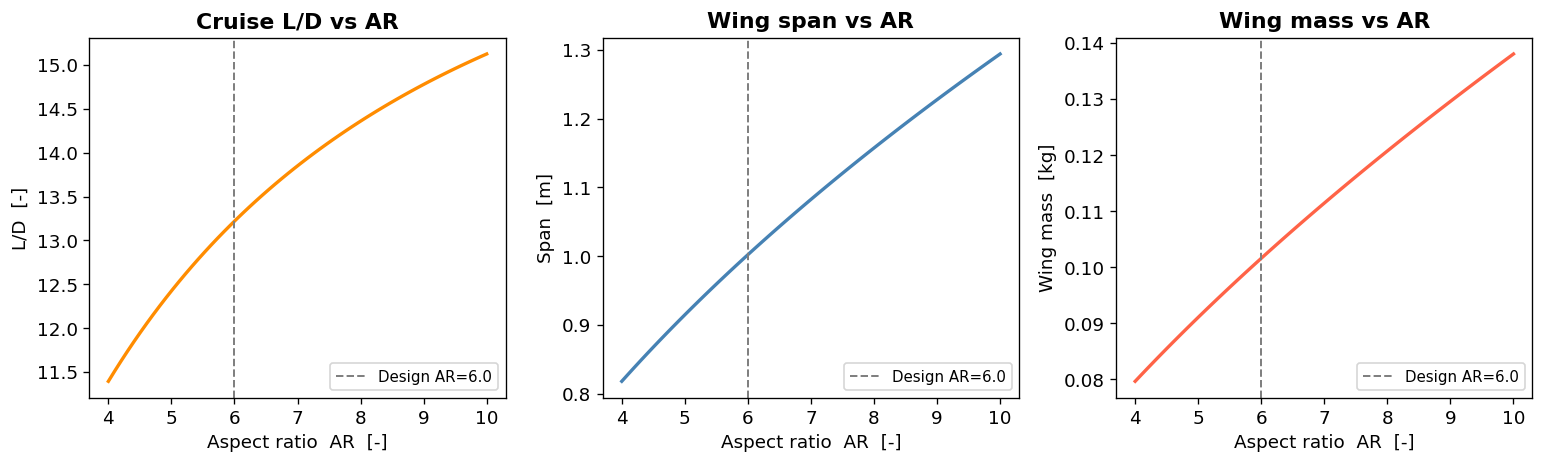

In [11]:
AR_values = np.linspace(4.0, 10.0, 60)
LD_vals, span_vals, m_wing_vals = [], [], []

for AR_i in AR_values:
    e_i   = oswald_efficiency(AR_i)
    k_i   = 1.0 / (math.pi * AR_i * e_i)
    CD_i  = CD0_total + k_i * CL_cruise**2
    LD_i  = CL_cruise / CD_i
    S_i   = W / WS_design
    b_i   = math.sqrt(AR_i * S_i)
    from conceptual_design.wing_sizing import wing_mass_raymer_kg
    m_i   = wing_mass_raymer_kg(S_i, AR_i, m_total, V_cruise, env.rho, ws)
    LD_vals.append(LD_i)
    span_vals.append(b_i)
    m_wing_vals.append(m_i)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax_i, ydata, ylabel, title, color in zip(
    axes,
    [LD_vals, span_vals, m_wing_vals],
    ['L/D  [-]', 'Span  [m]', 'Wing mass  [kg]'],
    ['Cruise L/D vs AR', 'Wing span vs AR', 'Wing mass vs AR'],
    ['darkorange', 'steelblue', 'tomato'],
):
    ax_i.plot(AR_values, ydata, lw=2, color=color)
    ax_i.axvline(aero.AR, color='gray', lw=1.2, ls='--',
                 label=f'Design AR={aero.AR}')
    ax_i.set_xlabel('Aspect ratio  AR  [-]')
    ax_i.set_ylabel(ylabel)
    ax_i.set_title(title, fontweight='bold')
    ax_i.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ar_trade.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

Final wing and airfoil design card for the electric V-BAT tail-sitter.

In [12]:
print()
print("+" + "="*56 + "+")
print("|  WING DESIGN CARD — Electric V-BAT Tail-Sitter          |")
print("+" + "="*56 + "+")
print(f"|  Airfoil designation   {DESIGNATION:<33}|")
print(f"|  t/c                   {ws.tc_ratio:.3f}{'':<30}|")
print(f"|  Camber (M)            {M:.4f}{'':<29}|")
print(f"|  Max camber loc (P)    {P:.2f}{'':<31}|")
print("+" + "="*56 + "+")
print(f"|  Wing area  S          {wing.S_wing:.4f} m^2{'':<25}|")
print(f"|  Span       b          {wing.b_wing:.4f} m{'':<27}|")
print(f"|  MAC chord  c          {wing.chord_mean:.4f} m{'':<27}|")
print(f"|  Aspect ratio AR       {aero.AR:.1f}{'':<32}|")
print(f"|  Wing loading (design) {WS_design:.1f} N/m^2{'':<23}|")
print(f"|  Wing mass (Raymer)    {wing.mass_wing_kg:.4f} kg{'':<25}|")
print("+" + "="*56 + "+")
print(f"|  Cl_alpha (2D)         {af.Cl_alpha_rad:.4f} /rad{'':<22}|")
print(f"|  CL_alpha (3D)         {af.CL_alpha_rad:.4f} /rad{'':<22}|")
print(f"|  CL_max (3D)           {af.CL_max_3D:.4f}{'':<29}|")
print(f"|  CL cruise             {af.CL_cruise:.4f}{'':<29}|")
print(f"|  L/D cruise            {af.LD_cruise:.2f}{'':<31}|")
print(f"|  Oswald e              {af.e_oswald:.4f}{'':<29}|")
print("+" + "="*56 + "+")
print(f"|  Stall speed           {V_stall:.2f} m/s{'':<27}|")
print(f"|  Re cruise             {Re_cruise:.2e}{'':<26}|")
print(f"|  Re stall              {Re_stall:.2e}{'':<26}|")
print("+" + "="*56 + "+")
if af.warnings:
    print("  CONSTRAINT WARNINGS:")
    for w in af.warnings:
        print(f"    ! {w}")
else:
    print("|  All design constraints: OK" + " "*28 + "|")
print("+" + "="*56 + "+")


+========================================================+
|  WING DESIGN CARD — Electric V-BAT Tail-Sitter          |
+========================================================+
|  Airfoil designation   NACA 2412                        |
|  t/c                   0.120                              |
|  Camber (M)            0.0200                             |
|  Max camber loc (P)    0.40                               |
+========================================================+
|  Wing area  S          0.1674 m^2                         |
|  Span       b          1.0022 m                           |
|  MAC chord  c          0.1670 m                           |
|  Aspect ratio AR       6.0                                |
|  Wing loading (design) 123.2 N/m^2                       |
|  Wing mass (Raymer)    0.1016 kg                         |
+========================================================+
|  Cl_alpha (2D)         6.8638 /rad                      |
|  CL_alpha (3D)         4.